In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

X_cols = [
    "Construction period",
    "Typology",
    "Primary Code",
    "Hybrid Structure",
    "Location_code",
]

y_cols = ["Concrete", "Glass", "Steel", "Wood", "Brick"]

In [15]:
class JointMDN(nn.Module):
    def __init__(self, input_dim: int = 5, M: int = 5, K: int = 3):
        super().__init__()
        self.input_dim = input_dim
        self.M = M
        self.K = K
        self.num_cholesky_params = M * (M + 1) // 2

        output_dim = K + (K * M) + (K * self.num_cholesky_params)
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
        )

    def build_cholesky(self, L_params: torch.Tensor) -> torch.Tensor:
        batch_size = L_params.shape[0]
        L = L_params.new_zeros(batch_size, self.K, self.M, self.M)

        tril_rows, tril_cols = torch.tril_indices(
            row=self.M, col=self.M, offset=0, device=L_params.device
        )
        L[:, :, tril_rows, tril_cols] = L_params

        diag_idx = torch.arange(self.M, device=L_params.device)
        L[:, :, diag_idx, diag_idx] = (
            F.softplus(L[:, :, diag_idx, diag_idx]) + 1e-6
        )
        return L

    def forward(self, x: torch.Tensor):
        output = self.network(x)

        pi_end = self.K
        mu_end = pi_end + (self.K * self.M)

        pi_logits = output[:, :pi_end]
        mu = output[:, pi_end:mu_end].view(-1, self.K, self.M)
        L_params = output[:, mu_end:].view(-1, self.K, self.num_cholesky_params)
        L = self.build_cholesky(L_params)

        return pi_logits, mu, L

In [16]:
def mdn_loss(pi_logits: torch.Tensor, mu: torch.Tensor, L: torch.Tensor, y_true: torch.Tensor):
    component_distribution = torch.distributions.MultivariateNormal(
        loc=mu, scale_tril=L
    )
    mixture_distribution = torch.distributions.Categorical(logits=pi_logits)
    joint_distribution = torch.distributions.MixtureSameFamily(
        mixture_distribution, component_distribution
    )

    log_prob = joint_distribution.log_prob(y_true)
    return -log_prob.mean()

In [17]:
def prepare_dataloaders(
    file_path: str | Path = "Integrated_MI_database.xlsx",
    batch_size: int = 64,
    random_state: int = 42,
):
    file_path = Path(file_path)
    if not file_path.is_absolute():
        file_path = Path.cwd() / file_path

    df = pd.read_excel(file_path)

    df["Construction period"] = pd.to_numeric(
        df["Construction period"], errors="coerce"
    )
    df = df.dropna(subset=X_cols + y_cols).reset_index(drop=True)

    X = df[X_cols].copy()
    y = np.log1p(df[y_cols].to_numpy(dtype=np.float32))

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=random_state
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=random_state
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), ["Construction period"]),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                ["Typology", "Primary Code", "Hybrid Structure", "Location_code"],
            ),
        ]
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_val)
    X_test_processed = preprocessor.transform(X_test)

    X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return {
        "X_train": X_train_tensor,
        "X_val": X_val_tensor,
        "X_test": X_test_tensor,
        "y_train": y_train_tensor,
        "y_val": y_val_tensor,
        "y_test": y_test_tensor,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "preprocessor": preprocessor,
    }

In [18]:
data = prepare_dataloaders()
print("Data preparation complete.")
print(f"X_train shape: {data['X_train'].shape}, y_train shape: {data['y_train'].shape}")
print(f"X_val shape:   {data['X_val'].shape}, y_val shape:   {data['y_val'].shape}")
print(f"X_test shape:  {data['X_test'].shape}, y_test shape:  {data['y_test'].shape}")

Data preparation complete.
X_train shape: torch.Size([632, 22]), y_train shape: torch.Size([632, 5])
X_val shape:   torch.Size([135, 22]), y_val shape:   torch.Size([135, 5])
X_test shape:  torch.Size([136, 22]), y_test shape:  torch.Size([136, 5])


In [19]:
# Training loop for JointMDN
input_dim = data["X_train"].shape[1]
model = JointMDN(input_dim=input_dim, M=5, K=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 100

train_loader = data["train_loader"]
val_loader = data["val_loader"]

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pi_logits, mu, L = model(X_batch)
        loss = mdn_loss(pi_logits, mu, L, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            pi_logits, mu, L = model(X_batch)
            loss = mdn_loss(pi_logits, mu, L, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d}/{epochs} - "
            f"Training Loss: {train_loss:.4f} - Validation Loss: {val_loss:.4f}"
        )

Epoch 010/100 - Training Loss: 6.7714 - Validation Loss: 6.8495
Epoch 020/100 - Training Loss: 5.7588 - Validation Loss: 6.2846
Epoch 030/100 - Training Loss: 5.0331 - Validation Loss: 5.6772
Epoch 040/100 - Training Loss: 3.5432 - Validation Loss: 4.4737
Epoch 050/100 - Training Loss: 3.3023 - Validation Loss: 4.3284
Epoch 060/100 - Training Loss: 3.1361 - Validation Loss: 4.3422
Epoch 070/100 - Training Loss: 3.0952 - Validation Loss: 4.2856
Epoch 080/100 - Training Loss: 2.9312 - Validation Loss: 4.6326
Epoch 090/100 - Training Loss: 2.8926 - Validation Loss: 4.4879
Epoch 100/100 - Training Loss: 2.8709 - Validation Loss: 4.4515


In [20]:
def predict_material_ranges(model, X_new_tensor, num_samples=1000):
    model.eval()
    with torch.no_grad():
        pi_logits, mu, L = model(X_new_tensor)

        component_distribution = torch.distributions.MultivariateNormal(
            loc=mu, scale_tril=L
        )
        mixture_distribution = torch.distributions.Categorical(logits=pi_logits)
        joint_distribution = torch.distributions.MixtureSameFamily(
            mixture_distribution, component_distribution
        )

        samples = joint_distribution.sample((num_samples,))
        percentiles = torch.quantile(
            samples, q=torch.tensor([0.05, 0.50, 0.95], device=samples.device), dim=0
        )

    percentiles_np = np.expm1(percentiles.cpu().numpy())

    result = {}
    for i, material in enumerate(y_cols):
        result[material] = {
            "p5": percentiles_np[0, :, i],
            "p50": percentiles_np[1, :, i],
            "p95": percentiles_np[2, :, i],
        }

    return result

In [22]:
def evaluate_mdn(model, X_test_tensor, y_test_df, num_samples=1000):
    prediction_ranges = predict_material_ranges(
        model, X_test_tensor, num_samples=num_samples
    )

    for material in y_cols:
        y_true = y_test_df[material].to_numpy()
        y_pred_median = prediction_ranges[material]["p50"]
        lower_bound = prediction_ranges[material]["p5"]
        upper_bound = prediction_ranges[material]["p95"]

        mae = np.mean(np.abs(y_pred_median - y_true))
        coverage = np.mean((y_true > lower_bound) & (y_true < upper_bound)) * 100

        print(f"{material}: MAE = {mae:.4f}, 90% Coverage = {coverage:.2f}%")

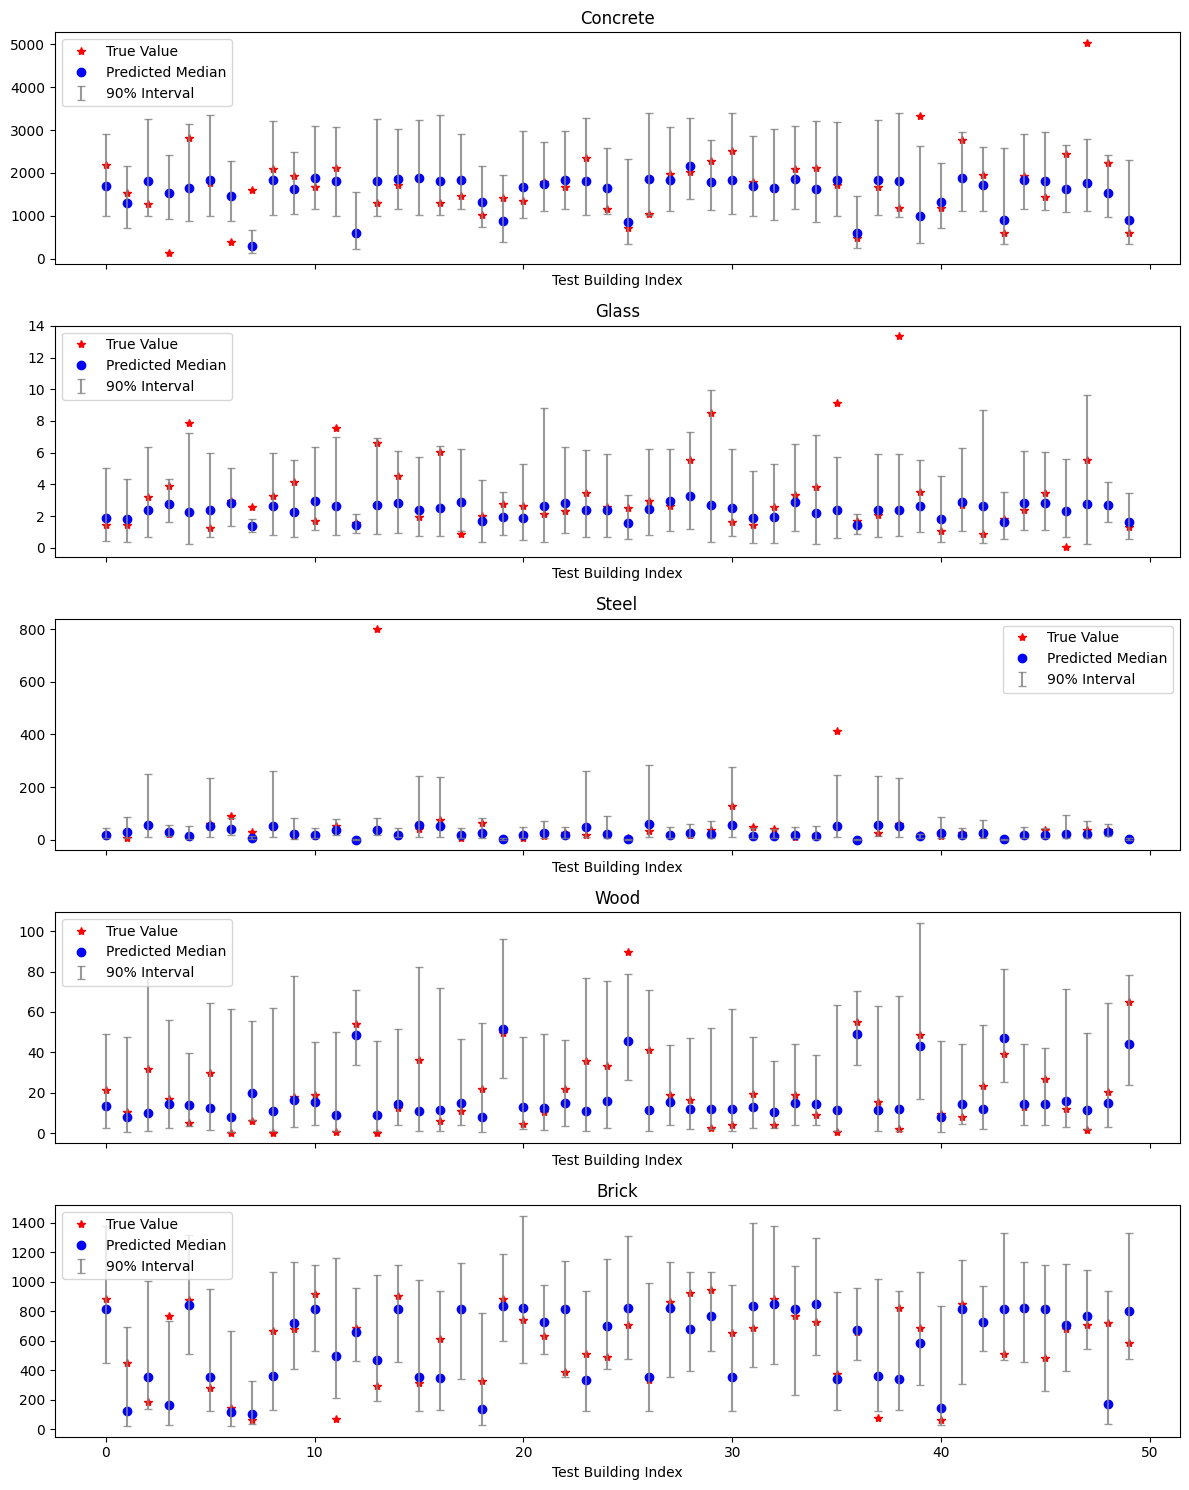

In [23]:
import matplotlib.pyplot as plt

# Build y_test_df in original kg/m² units from the stored test tensor
# (the tensors in `data` are log-transformed, so we back-transform here)
y_test_df = pd.DataFrame(
    np.expm1(data["y_test"].cpu().numpy()), columns=y_cols
)

# Predict ranges for the first 50 buildings in the test set
X_test_first50 = data["X_test"][:50]
pred_ranges = predict_material_ranges(model, X_test_first50, num_samples=1000)

fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
x_idx = np.arange(50)

for i, material in enumerate(y_cols):
    ax = axes[i]
    y_true = y_test_df[material].iloc[:50].to_numpy()
    y_med = pred_ranges[material]["p50"]
    y_low = pred_ranges[material]["p5"]
    y_high = pred_ranges[material]["p95"]

    ax.plot(x_idx, y_true, "r*", label="True Value")
    ax.plot(x_idx, y_med, "bo", label="Predicted Median")
    ax.errorbar(
        x_idx,
        y_med,
        yerr=[y_med - y_low, y_high - y_med],
        fmt="none",
        ecolor="gray",
        alpha=0.8,
        capsize=3,
        label="90% Interval",
    )

    ax.set_title(material)
    ax.set_xlabel("Test Building Index")
    ax.legend()

plt.tight_layout()
plt.show()

In [24]:
# Print model performance on the full test set
evaluate_mdn(model, data["X_test"], y_test_df, num_samples=1000)

Concrete: MAE = 430.9260, 90% Coverage = 91.91%
Glass: MAE = 1.5674, 90% Coverage = 88.97%
Steel: MAE = 41.6465, 90% Coverage = 86.03%
Wood: MAE = 9.3070, 90% Coverage = 86.03%
Brick: MAE = 155.5101, 90% Coverage = 94.12%


In [25]:
import joblib

joblib.dump(data["preprocessor"], "preprocessor.joblib")
torch.save(model.state_dict(), "mdn_model_weights.pth")

print("Saved preprocessor.joblib and mdn_model_weights.pth")

Saved preprocessor.joblib and mdn_model_weights.pth
